In [3]:
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer
import pandas as  pd
import numpy as np

In [ ]:

analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_7B/munsell_colors_describe',
                                     'data/colors/munsell_colors/munsell_manifest.csv')
embeddings = analyzer.chain_loader.get_all_available_embeddings()

/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# PCA анализ векторов эмбеддингов LLM декодера и vision энкодера мультимодальной большой языковой модели QWEN 2.5 7B

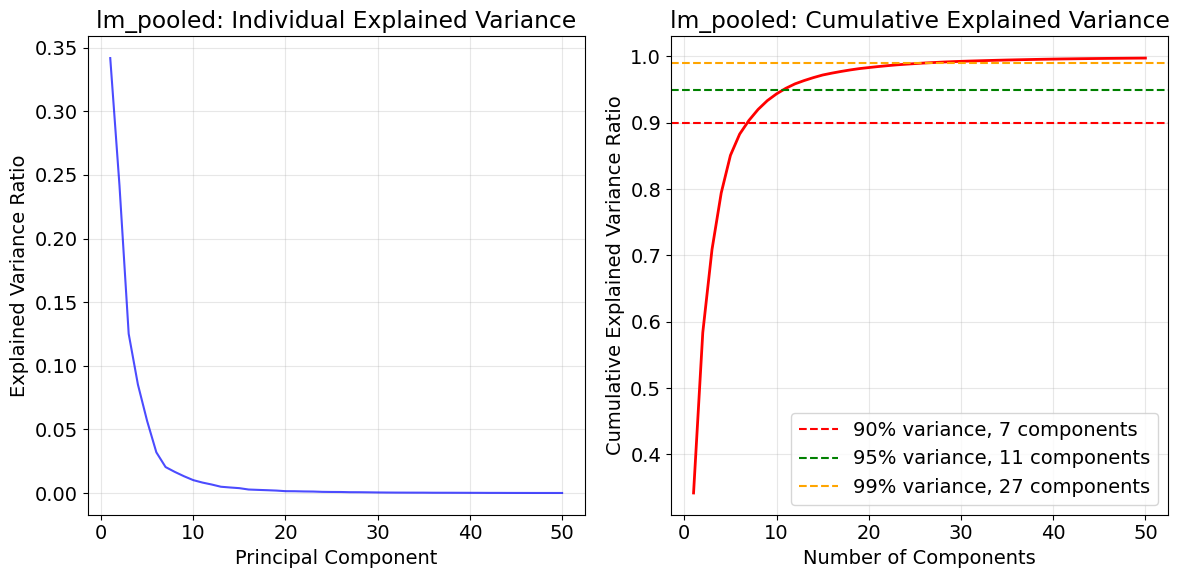

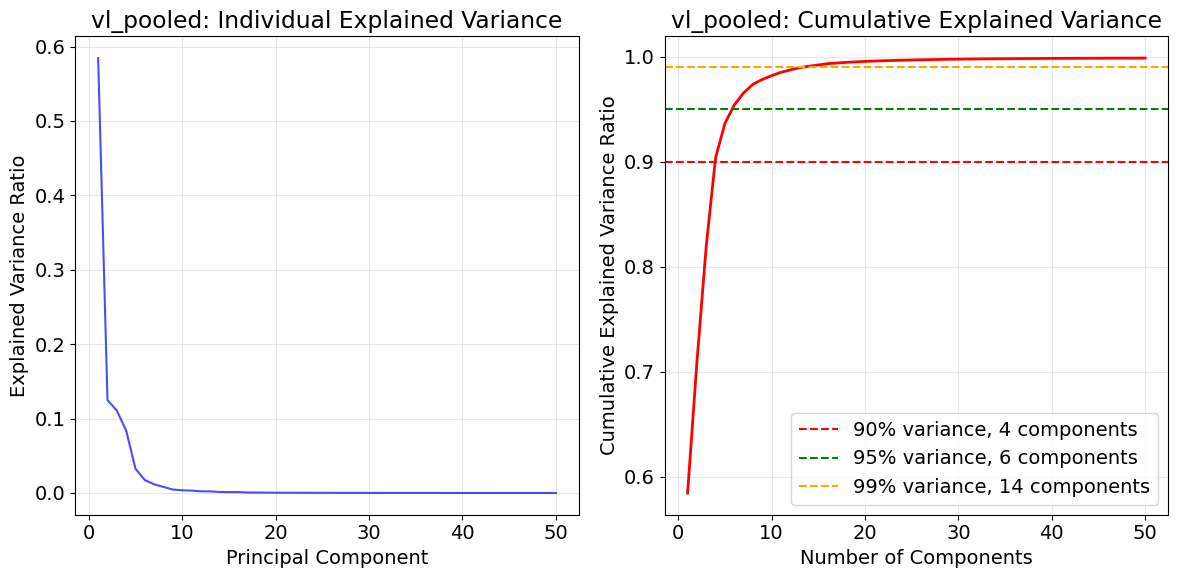

In [3]:
pca_result = analyzer.pca_by_embeddings(embeddings)

analyzer.plot_pca_variance(pca_result, embedding_name='lm_pooled')
analyzer.plot_pca_variance(pca_result, embedding_name='vl_pooled')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.linear_model import LinearRegression

def intrinsic_dimension_knn_regression(X, k=20):
    """
    Оценка ID методом k-NN регрессии (Slope of log-log plot).
    log(k) = d * log(R_k) + C
    """
    n = X.shape[0]
    # Те же предобработки: L2 нормализация
    X_norm = normalize(X, norm='l2')
    
    neigh = NearestNeighbors(n_neighbors=k+1, metric='euclidean', n_jobs=-1)
    neigh.fit(X_norm)
    dists, _ = neigh.kneighbors(X_norm)
    
    # Отбрасываем 0-го соседа (себя)
    dists = dists[:, 1:]
    
    # Массив рангов соседей: [1, 2, ..., k]
    ks = np.arange(1, k + 1)
    log_ks = np.log(ks).reshape(-1, 1) # X для регрессии (но мы поменяем местами для d)
    
    local_dims = []
    
    # Для каждой точки строим регрессию
    # Нам нужно d = slope(log(R), log(k))
    # Y = log(k), X = log(R) -> Y = d*X + C
    
    for i in range(n):
        # Берем расстояния для i-й точки
        r_vals = dists[i]
        
        # Защита от нулевых расстояний (дубликатов)
        r_vals = np.maximum(r_vals, 1e-10)
        
        log_r = np.log(r_vals).reshape(-1, 1)
        
        # Линейная регрессия
        model = LinearRegression()
        model.fit(log_r, log_ks) # fit(X, y)
        
        # Коэффициент наклона и есть размерность
        slope = model.coef_[0][0]
        local_dims.append(slope)
        
    return np.mean(local_dims), np.array(local_dims)

--- Сравнение методов (k=20) ---
k-NN Regression (LLM):     Mean = 2.347, Std = 0.832
k-NN Regression (VL):     Mean = 2.719, Std = 0.975
--- MLE (Levina-Bickel) ---
LLM: Mean = 2.831, Std = 1.011
VL: Mean = 3.079, Std = 0.960


/var/folders/4m/l3r2f5js3z959cxtw9_5q5pr0000gn/T/ipykernel_14584/1302147335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


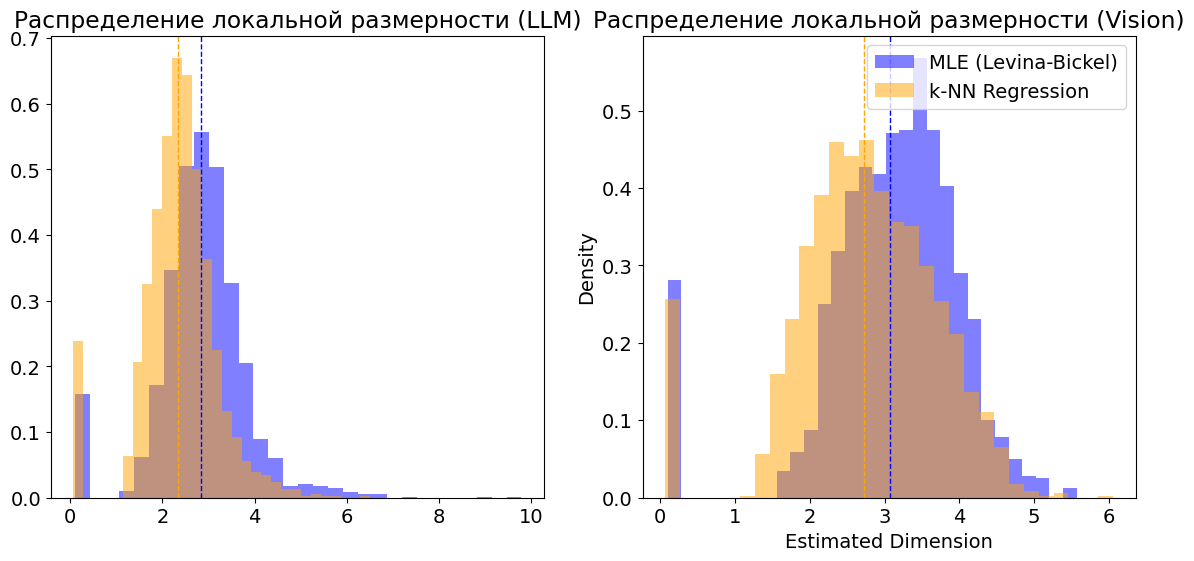

In [4]:

def intrinsic_dimension_mle_short(X, k=20):
    X_norm = normalize(X, norm='l2')
    neigh = NearestNeighbors(n_neighbors=k+1, metric='euclidean', n_jobs=-1)
    neigh.fit(X_norm)
    dists, _ = neigh.kneighbors(X_norm)
    dists = dists[:, 1:]
    T_k = dists[:, -1].reshape(-1, 1)
    T_j = dists[:, :-1]
    epsilon = 1e-10
    local_ids = (k - 2) / np.sum(np.log(np.maximum(T_k, epsilon) / np.maximum(T_j, epsilon)), axis=1)
    return np.mean(local_ids), local_ids

mean_mle_llm, vals_mle_llm = intrinsic_dimension_mle_short(embeddings['lm_pooled'], k=20)
mean_mle_vl, vals_mle_vl = intrinsic_dimension_mle_short(embeddings['vl_pooled'], k=20)

# 2. Запуск k-NN Regression на LLM и VL
mean_reg_llm, vals_reg_llm = intrinsic_dimension_knn_regression(embeddings['lm_pooled'], k=20)
mean_reg_vl, vals_reg_vl = intrinsic_dimension_knn_regression(embeddings['vl_pooled'], k=20)


print(f"--- Сравнение методов (k=20) ---")
print(f"k-NN Regression (LLM):     Mean = {mean_reg_llm:.3f}, Std = {np.std(vals_reg_llm):.3f}")
print(f"k-NN Regression (VL):     Mean = {mean_reg_vl:.3f}, Std = {np.std(vals_reg_vl):.3f}")
print(f"--- MLE (Levina-Bickel) ---")
print(f"LLM: Mean = {mean_mle_llm:.3f}, Std = {np.std(vals_mle_llm):.3f}")
print(f"VL: Mean = {mean_mle_vl:.3f}, Std = {np.std(vals_mle_vl):.3f}")

# Визуализация распределения оценок
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].set_title('Распределение локальной размерности (LLM)')
axes[0].hist(vals_mle_llm, bins=30, alpha=0.5, label='MLE (Levina-Bickel)', color='blue', density=True)
axes[0].hist(vals_reg_llm, bins=30, alpha=0.5, label='k-NN Regression', color='orange', density=True)
axes[0].axvline(mean_mle_llm, color='blue', linestyle='dashed', linewidth=1)
axes[0].axvline(mean_reg_llm, color='orange', linestyle='dashed', linewidth=1)

axes[1].set_title('Распределение локальной размерности (Vision)')
axes[1].set_xlabel('Estimated Dimension')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].hist(vals_mle_vl, bins=30, alpha=0.5, label='MLE (Levina-Bickel)', color='blue', density=True)
axes[1].hist(vals_reg_vl, bins=30, alpha=0.5, label='k-NN Regression', color='orange', density=True)
axes[1].axvline(mean_mle_vl, color='blue', linestyle='dashed', linewidth=1)
axes[1].axvline(mean_reg_vl, color='orange', linestyle='dashed', linewidth=1)

plt.xlabel('Estimated Dimension')
plt.ylabel('Density')
plt.legend()
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# X - ваши данные (num_samples, 3400)
# 1. Нормализация (обязательно для эмбеддингов)
X_norm = normalize(embeddings['lm_pooled'], norm='l2')

# 2. Isomap: Попытка развернуть многообразие в 3D
# n_neighbors должно быть согласовано с тем k, где MLE давал стабильный результат (15-20)
iso = Isomap(n_neighbors=20, n_components=3)
X_iso = iso.fit_transform(X_norm)

# 3. PCA: Для сравнения (проекция на плоскость)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_norm)

# 4. Оценка качества: Reconstruction Error (Residual Variance)
# Насколько хорошо мы сохранили расстояния?
# Считаем корреляцию между расстояниями в 3400D (геодезическими) и 3D

from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr

# Аппроксимация геодезических расстояний в исходном пространстве (через граф)
dist_geo_high = iso.dist_matrix_ # Isomap сам считает это внутри
# Берем только верхний треугольник матрицы, чтобы не дублировать
mask = np.triu_indices_from(dist_geo_high, k=1)

# Расстояния в полученном 3D пространстве
dist_iso_low = pairwise_distances(X_iso)
dist_pca_low = pairwise_distances(X_pca)

corr_iso, _ = pearsonr(dist_geo_high[mask], dist_iso_low[mask])
corr_pca, _ = pearsonr(dist_geo_high[mask], dist_pca_low[mask])

print(f"Корреляция расстояний (Isomap 3D): {corr_iso:.4f}")
print(f"Корреляция расстояний (PCA 3D):    {corr_pca:.4f}")

Корреляция расстояний (Isomap 3D): 0.9656
Корреляция расстояний (PCA 3D):    0.9076


## Fixed ISOMAP and PCA 3D with Pearson Correlation (using new methods)

In [11]:
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist
import numpy as np

# Reload analyzer and data
analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_3B/describe_color',
                                     'data/colors/munsell_colors/munsell_manifest.csv')
embeddings = analyzer.chain_loader.get_all_available_embeddings()
meta = pd.DataFrame(analyzer.chain_loader.get_all_available_colors())

print(f"Embeddings: lm_pooled={embeddings['lm_pooled'].shape}, vl_pooled={embeddings['vl_pooled'].shape}")
print(f"Metadata: {meta.shape}")

# 3D PCA using new method
pca_result = analyzer.pca_all_embeddings(n_components=3)
print("\n=== 3D PCA Visualization ===")
MunsellEmbeddingsAnalyzer.plot_pca_3d(pca_result, 'lm_pooled')
MunsellEmbeddingsAnalyzer.plot_pca_3d(pca_result, 'vl_pooled')

# ISOMAP using new method
print("\n=== ISOMAP 3D Visualization ===")
isomap_result = analyzer.isomap_all_embeddings(n_components=3, n_neighbors=100)
MunsellEmbeddingsAnalyzer.plot_isomap_results(isomap_result, 'lm_pooled')
MunsellEmbeddingsAnalyzer.plot_isomap_results(isomap_result, 'vl_pooled')

Embeddings: lm_pooled=(1755, 2048), vl_pooled=(1755, 2048)
Metadata: (1755, 8)

=== 3D PCA Visualization ===



=== ISOMAP 3D Visualization ===


In [12]:
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist
import numpy as np

# Reload analyzer and data
analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_7B/munsell_colors_describe',
                                     'data/colors/munsell_colors/munsell_manifest.csv')
embeddings = analyzer.chain_loader.get_all_available_embeddings()
meta = pd.DataFrame(analyzer.chain_loader.get_all_available_colors())

print(f"Embeddings: lm_pooled={embeddings['lm_pooled'].shape}, vl_pooled={embeddings['vl_pooled'].shape}")
print(f"Metadata: {meta.shape}")

# 3D PCA using new method
pca_result = analyzer.pca_all_embeddings(n_components=3)
print("\n=== 3D PCA Visualization ===")
MunsellEmbeddingsAnalyzer.plot_pca_3d(pca_result, 'lm_pooled')
MunsellEmbeddingsAnalyzer.plot_pca_3d(pca_result, 'vl_pooled')

# ISOMAP using new method
print("\n=== ISOMAP 3D Visualization ===")
isomap_result = analyzer.isomap_all_embeddings(n_components=3, n_neighbors=100)
MunsellEmbeddingsAnalyzer.plot_isomap_results(isomap_result, 'lm_pooled')
MunsellEmbeddingsAnalyzer.plot_isomap_results(isomap_result, 'vl_pooled')

Embeddings: lm_pooled=(1755, 3584), vl_pooled=(1755, 3584)
Metadata: (1755, 8)

=== 3D PCA Visualization ===



=== ISOMAP 3D Visualization ===


## InternVL 2B

In [6]:
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist
import numpy as np

# Reload analyzer and data
analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/InternVL3-2B_debug/describe_color',
                                     'data/colors/munsell_colors/munsell_manifest.csv')
embeddings = analyzer.chain_loader.get_all_available_embeddings()
meta = pd.DataFrame(analyzer.chain_loader.get_all_available_colors())

print(f"Embeddings: lm_pooled={embeddings['lm_pooled'].shape}, vl_pooled={embeddings['vl_pooled'].shape}")
print(f"Metadata: {meta.shape}")

# 3D PCA using new method
pca_result = analyzer.pca_all_embeddings(n_components=3)
print("\n=== 3D PCA Visualization ===")
MunsellEmbeddingsAnalyzer.plot_pca_3d(pca_result, 'lm_pooled')
MunsellEmbeddingsAnalyzer.plot_pca_3d(pca_result, 'vl_pooled')

# ISOMAP using new method
print("\n=== ISOMAP 3D Visualization ===")
isomap_result = analyzer.isomap_all_embeddings(n_components=3, n_neighbors=100)
MunsellEmbeddingsAnalyzer.plot_isomap_results(isomap_result, 'lm_pooled')
MunsellEmbeddingsAnalyzer.plot_isomap_results(isomap_result, 'vl_pooled')

Embeddings: lm_pooled=(1755, 1536), vl_pooled=(1755, 1024)
Metadata: (1755, 8)

=== 3D PCA Visualization ===



=== ISOMAP 3D Visualization ===


In [7]:
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist
import numpy as np

# Reload analyzer and data
analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/InternVL3-8B_debug/describe_color',
                                     'data/colors/munsell_colors/munsell_manifest.csv')
embeddings = analyzer.chain_loader.get_all_available_embeddings()
meta = pd.DataFrame(analyzer.chain_loader.get_all_available_colors())

print(f"Embeddings: lm_pooled={embeddings['lm_pooled'].shape}, vl_pooled={embeddings['vl_pooled'].shape}")
print(f"Metadata: {meta.shape}")

# 3D PCA using new method
pca_result = analyzer.pca_all_embeddings(n_components=3)
print("\n=== 3D PCA Visualization ===")
MunsellEmbeddingsAnalyzer.plot_pca_3d(pca_result, 'lm_pooled')
MunsellEmbeddingsAnalyzer.plot_pca_3d(pca_result, 'vl_pooled')

# ISOMAP using new method
print("\n=== ISOMAP 3D Visualization ===")
isomap_result = analyzer.isomap_all_embeddings(n_components=3, n_neighbors=100)
MunsellEmbeddingsAnalyzer.plot_isomap_results(isomap_result, 'lm_pooled')
MunsellEmbeddingsAnalyzer.plot_isomap_results(isomap_result, 'vl_pooled')

Embeddings: lm_pooled=(1755, 3584), vl_pooled=(1755, 1024)
Metadata: (1755, 8)

=== 3D PCA Visualization ===



=== ISOMAP 3D Visualization ===


In [14]:
from colour import XYZ_to_CAM16UCS, xyY_to_XYZ
colors_all = meta["RGB"].values
XYZ_all = np.array([xyY_to_XYZ(xyy) for xyy in meta["xyY"].values]) / 100
cam_all = np.array([XYZ_to_CAM16UCS(xyz) for xyz in XYZ_all])

In [15]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=cam_all[:, 0],
    y=cam_all[:, 1],
    z=cam_all[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=colors_all,
        opacity=0.8,
        line=dict(width=0)
    ),
    hoverinfo='text'
)])


# fig.update_layout(
#     title=title,
#     scene=dict(
#         xaxis_title='PC1',
#         yaxis_title='PC2',
#         zaxis_title='PC3'
#     ),
#     margin=dict(l=0, r=0, b=0, t=60)
# )
fig.update_layout(
    scene=dict(
        xaxis=dict(
            visible=False,           # Hide axis line
            showticklabels=False,    # Hide tick labels
            showgrid=False,          # Hide grid lines
            showline=False,          # Hide axis line
            showbackground=False,    # Hide axis background
            zeroline=False           # Hide zero line
        ),
        yaxis=dict(
            visible=False,
            showticklabels=False,
            showgrid=False,
            showline=False,
            showbackground=False,
            zeroline=False
        ),
        zaxis=dict(
            visible=False,
            showticklabels=False,
            showgrid=False,
            showline=False,
            showbackground=False,
            zeroline=False
        ),
        # Remove the gray cube background
        bgcolor='rgba(0,0,0,0)',
        # Remove the axis lines and planes
        aspectmode='data',  # Keeps point proportions
    ),
    # Remove all margins and background
    margin=dict(l=0, r=0, t=0, b=0),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    # Remove title if you don't want it
    showlegend=False
)
fig.show()

In [3]:
def rgb_to_array(rgb_series):
    """Convert RGB series to numpy array, handling size mismatch."""
    rgb_list = []
    for rgb in rgb_series:
        if isinstance(rgb, str):
            rgb_arr = np.fromstring(rgb.strip('()'), sep=',')
        else:
            rgb_arr = np.array(rgb)
        rgb_list.append(rgb_arr)
    return np.array(rgb_list)

# Convert RGB to array
rgb_array = rgb_to_array(isomap_result['lm_pooled']['meta_filtered']['RGB'])
print(f"RGB array shape: {rgb_array.shape}")

# Ensure consistent sizes by using minimum length
min_len = min(len(embeddings['lm_pooled']), len(embeddings['vl_pooled']), len(rgb_array))
print(f"Using {min_len} samples for correlation analysis")

def calculate_correlation(embedding_matrix, rgb_matrix, method_name, n_samples=None):
    """Calculate Pearson correlation between embedding distances and RGB distances."""
    if n_samples is not None:
        emb = embedding_matrix[:n_samples]
        rgb = rgb_matrix[:n_samples]
    else:
        emb = embedding_matrix
        rgb = rgb_matrix
    emb_distances = pdist(emb, metric='cosine')
    rgb_distances = pdist(rgb, metric='euclidean')
    correlation, p_value = pearsonr(emb_distances, rgb_distances)
    print(f"{method_name}: Pearson r = {correlation:.4f}, p-value = {p_value:.2e}")
    return correlation, p_value

def calculate_dr_correlation(embedding_result, rgb_matrix, method_name, n_samples=None):
    """Calculate Pearson correlation from dimensionality reduction results."""
    if n_samples is not None:
        emb = embedding_result[:n_samples]
        rgb = rgb_matrix[:n_samples]
    else:
        emb = embedding_result
        rgb = rgb_matrix
    emb_distances = pdist(emb, metric='euclidean')
    rgb_distances = pdist(rgb, metric='euclidean')
    correlation, p_value = pearsonr(emb_distances, rgb_distances)
    print(f"{method_name}: Pearson r = {correlation:.4f}, p-value = {p_value:.2e}")
    return correlation, p_value

print("\n=== Pearson Correlation: Original Embeddings (cosine distance) ===")
corr_lm, _ = calculate_correlation(embeddings['lm_pooled'], rgb_array, "Original LM", min_len)
corr_vl, _ = calculate_correlation(embeddings['vl_pooled'], rgb_array, "Original VL", min_len)

print("\n=== Pearson Correlation: ISOMAP 3D (euclidean distance) ===")
if 'lm_pooled' in isomap_result and isomap_result['lm_pooled'] is not None:
    corr_iso_lm, _ = calculate_dr_correlation(
        isomap_result['lm_pooled']['embedding_result'], rgb_array, "ISOMAP 3D LM", min_len)
if 'vl_pooled' in isomap_result and isomap_result['vl_pooled'] is not None:
    corr_iso_vl, _ = calculate_dr_correlation(
        isomap_result['vl_pooled']['embedding_result'], rgb_array, "ISOMAP 3D VL", min_len)

print("\n=== Pearson Correlation: PCA 3D (euclidean distance) ===")
if 'lm_pooled' in pca_result and pca_result['lm_pooled'] is not None:
    corr_pca_lm, _ = calculate_dr_correlation(
        pca_result['lm_pooled']['pca_result'][:, :3], rgb_array, "PCA 3D LM", min_len)
if 'vl_pooled' in pca_result and pca_result['vl_pooled'] is not None:
    corr_pca_vl, _ = calculate_dr_correlation(
        pca_result['vl_pooled']['pca_result'][:, :3], rgb_array, "PCA 3D VL", min_len)

RGB array shape: (1674, 3)
Using 1674 samples for correlation analysis

=== Pearson Correlation: Original Embeddings (cosine distance) ===
Original LM: Pearson r = 0.0897, p-value = 0.00e+00
Original VL: Pearson r = 0.0695, p-value = 0.00e+00

=== Pearson Correlation: ISOMAP 3D (euclidean distance) ===
ISOMAP 3D LM: Pearson r = 0.7881, p-value = 0.00e+00
ISOMAP 3D VL: Pearson r = 0.5721, p-value = 0.00e+00

=== Pearson Correlation: PCA 3D (euclidean distance) ===
PCA 3D LM: Pearson r = 0.7655, p-value = 0.00e+00
PCA 3D VL: Pearson r = 0.5156, p-value = 0.00e+00


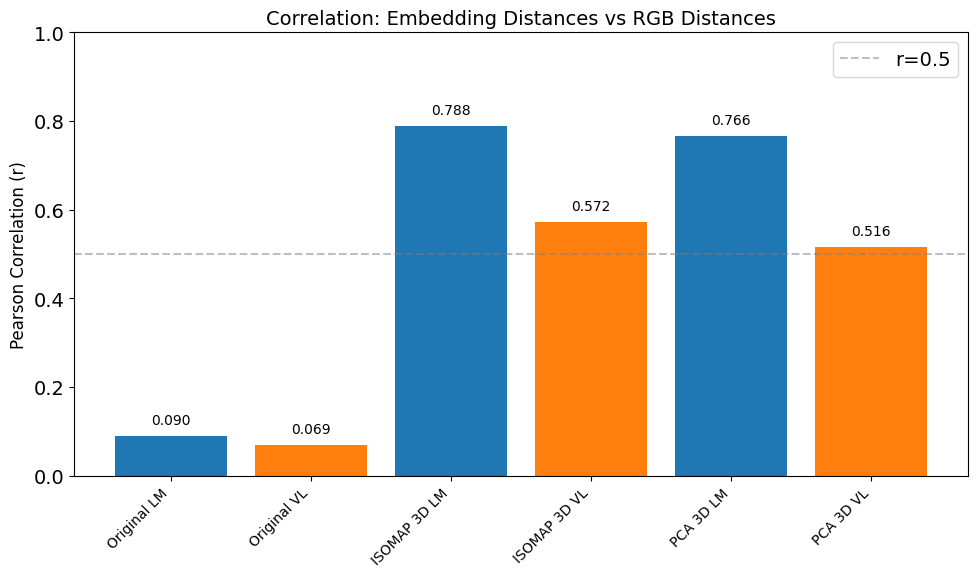


=== Summary ===
Best correlation: 0.7881 (ISOMAP 3D LM)
Worst correlation: 0.0695 (Original VL)


In [4]:
import matplotlib.pyplot as plt

# Create summary visualization
methods = ['Original LM', 'Original VL', 'ISOMAP 3D LM', 'ISOMAP 3D VL', 'PCA 3D LM', 'PCA 3D VL']
correlations = [corr_lm, corr_vl, corr_iso_lm, corr_iso_vl, corr_pca_lm, corr_pca_vl]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#1f77b4', '#ff7f0e', '#1f77b4', '#ff7f0e']
bars = ax.bar(methods, correlations, color=colors)

ax.set_ylabel('Pearson Correlation (r)', fontsize=12)
ax.set_title('Correlation: Embedding Distances vs RGB Distances', fontsize=14)
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='r=0.5')
ax.legend()

for bar, corr in zip(bars, correlations):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{corr:.3f}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('embedding_correlation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Summary ===")
print(f"Best correlation: {max(correlations):.4f} ({methods[correlations.index(max(correlations))]})")
print(f"Worst correlation: {min(correlations):.4f} ({methods[correlations.index(min(correlations))]})")

In [7]:
components = np.arange(2, 9)

correlations = {}

for n_comp in components:
    lm_pca = analyzer.pca_all_embeddings(n_components=n_comp)['lm_pooled']['pca_result']
    vl_pca = analyzer.pca_all_embeddings(n_components=n_comp)['vl_pooled']['pca_result']
    lm_iso = analyzer.isomap_all_embeddings(n_components=n_comp, n_neighbors=20)['lm_pooled']['embedding_result']
    vl_iso = analyzer.isomap_all_embeddings(n_components=n_comp, n_neighbors=20)['vl_pooled']['embedding_result']
    
    corr_lm_pca, _ = calculate_dr_correlation(lm_pca, rgb_array, f"PCA {n_comp}D LM", min_len)
    corr_vl_pca, _ = calculate_dr_correlation(vl_pca, rgb_array, f"PCA {n_comp}D VL", min_len)
    corr_lm_iso, _ = calculate_dr_correlation(lm_iso, rgb_array, f"ISOMAP {n_comp}D LM", min_len)
    corr_vl_iso, _ = calculate_dr_correlation(vl_iso, rgb_array, f"ISOMAP {n_comp}D VL", min_len)
    
    correlations[f'PCA_{n_comp}_LM'] = corr_lm_pca
    correlations[f'PCA_{n_comp}_VL'] = corr_vl_pca
    correlations[f'ISOMAP_{n_comp}_LM'] = corr_lm_iso
    correlations[f'ISOMAP_{n_comp}_VL'] = corr_vl_iso

PCA 2D LM: Pearson r = 0.7923, p-value = 0.00e+00
PCA 2D VL: Pearson r = 0.6034, p-value = 0.00e+00
ISOMAP 2D LM: Pearson r = 0.7338, p-value = 0.00e+00
ISOMAP 2D VL: Pearson r = 0.5308, p-value = 0.00e+00
PCA 3D LM: Pearson r = 0.7923, p-value = 0.00e+00
PCA 3D VL: Pearson r = 0.6034, p-value = 0.00e+00
ISOMAP 3D LM: Pearson r = 0.7881, p-value = 0.00e+00
ISOMAP 3D VL: Pearson r = 0.5721, p-value = 0.00e+00
PCA 4D LM: Pearson r = 0.7923, p-value = 0.00e+00
PCA 4D VL: Pearson r = 0.6034, p-value = 0.00e+00
ISOMAP 4D LM: Pearson r = 0.7926, p-value = 0.00e+00
ISOMAP 4D VL: Pearson r = 0.6328, p-value = 0.00e+00
PCA 5D LM: Pearson r = 0.7923, p-value = 0.00e+00
PCA 5D VL: Pearson r = 0.6034, p-value = 0.00e+00
ISOMAP 5D LM: Pearson r = 0.8002, p-value = 0.00e+00
ISOMAP 5D VL: Pearson r = 0.6309, p-value = 0.00e+00
PCA 6D LM: Pearson r = 0.7923, p-value = 0.00e+00
PCA 6D VL: Pearson r = 0.6034, p-value = 0.00e+00
ISOMAP 6D LM: Pearson r = 0.8000, p-value = 0.00e+00
ISOMAP 6D VL: Pearson r

In [4]:
dist = analyzer.calculate_all_embeddings_distances()

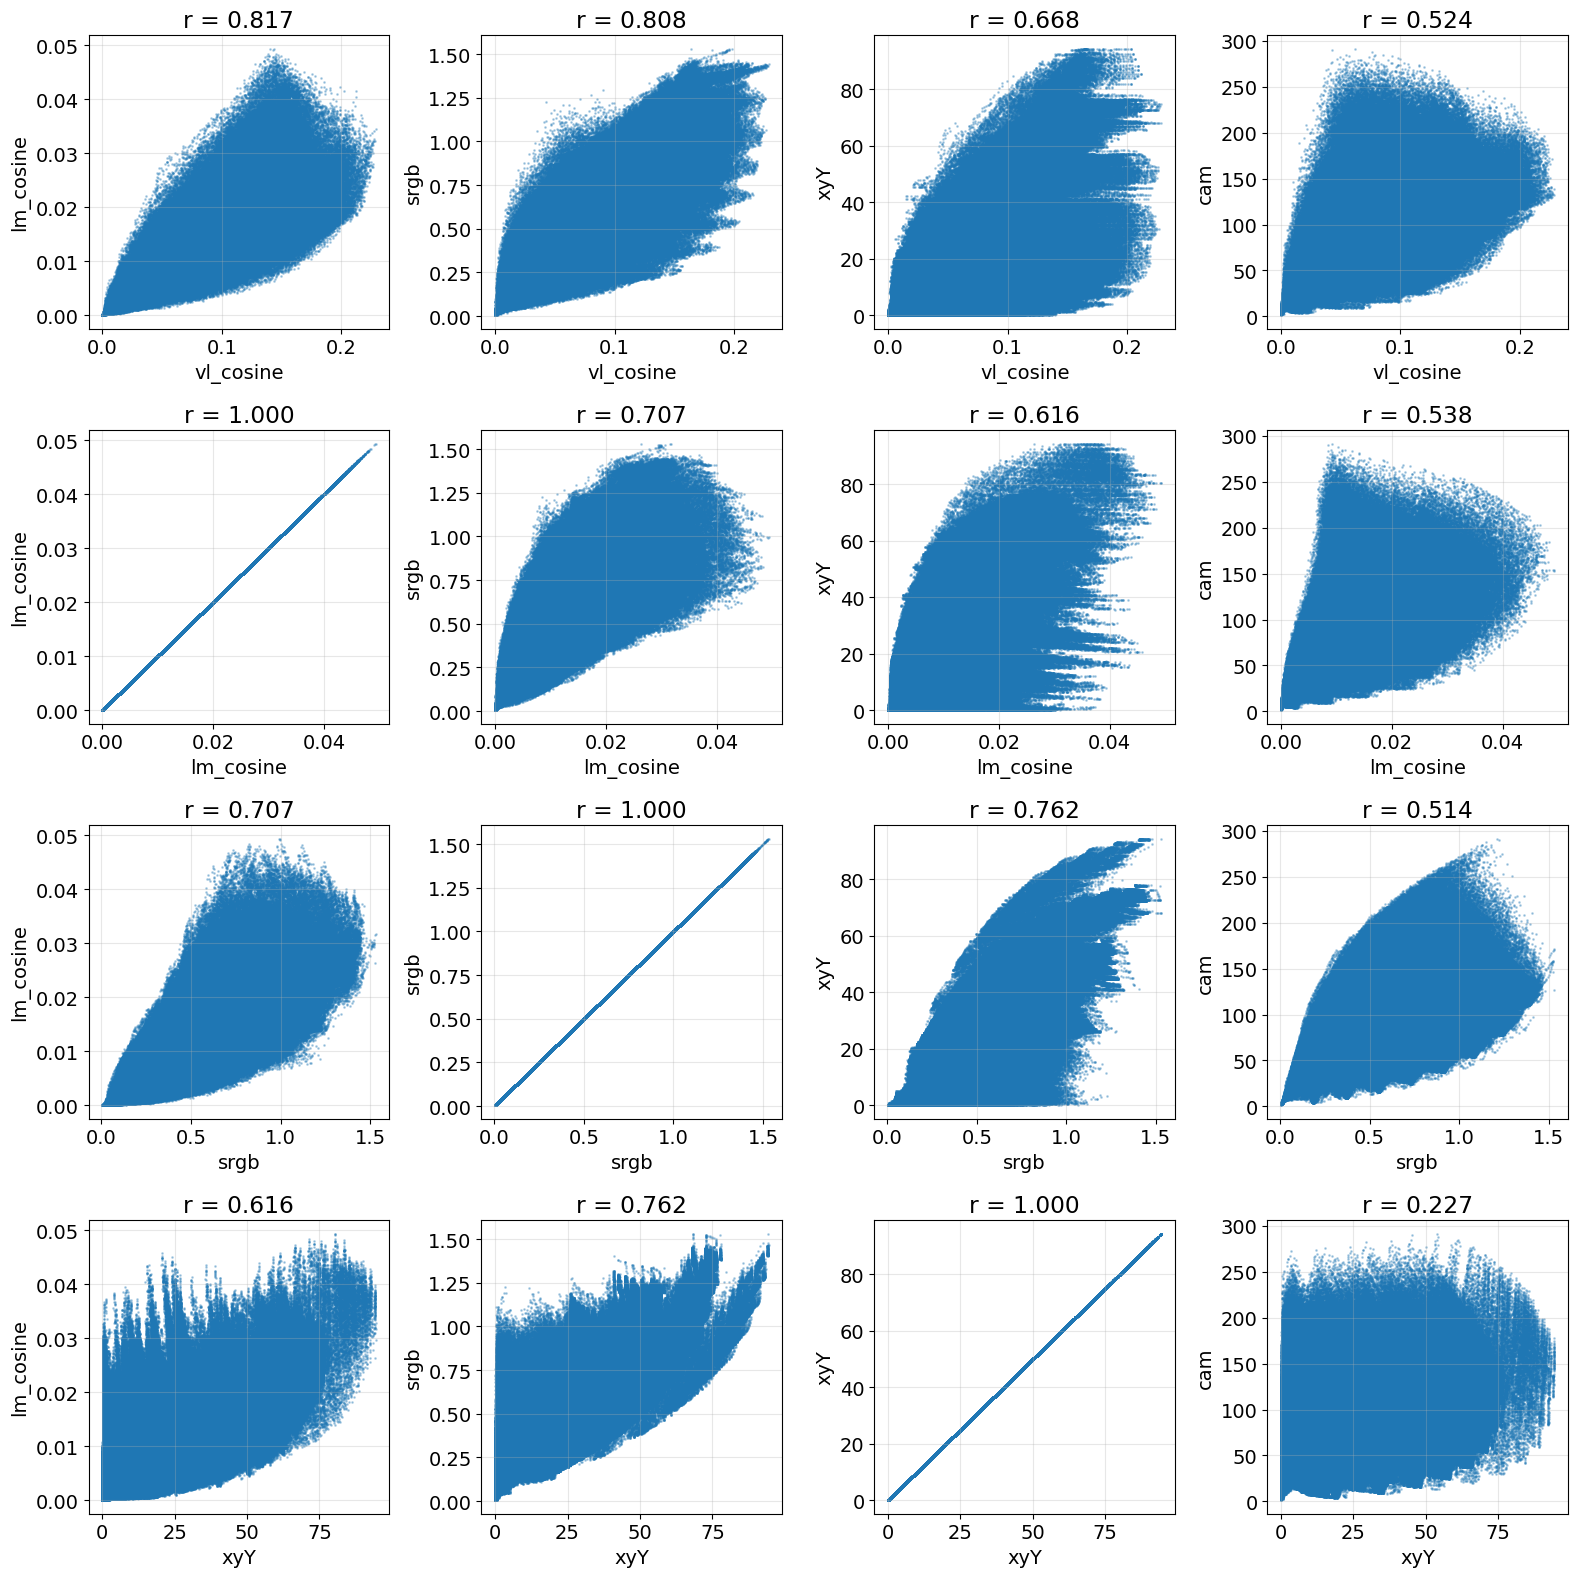

In [11]:
# Visualization
fig, ax = analyzer.plot_distance_correlations(distances_dict=dist, show=False)
fig.savefig('dist_res.png')